IMPORTAÇÃO BIBLIOTECA PANDAS

In [ ]:
import pandas as pd

DADOS VINDOS DE UMA LISTA

In [ ]:
# Dados das preferências de transporte
transporte = [
    "Carro", "Ônibus", "Bicicleta", "Carro", "Metrô", "Ônibus",
    "Bicicleta", "Carro", "Metrô", "Bicicleta", "Carro", "Ônibus",
    "Bicicleta", "Carro", "Metrô", "Carro", "Ônibus", "Bicicleta",
    "Carro", "Metrô", "Ônibus", "Bicicleta", "Metrô", "Carro",
    "Bicicleta", "Carro", "Metrô", "Ônibus", "Carro", "Bicicleta",
    "Metrô", "Ônibus", "Carro", "Bicicleta", "Ônibus", "Metrô",
    "Carro", "Ônibus", "Metrô", "Bicicleta", "Carro", "Metrô",
    "Bicicleta", "Ônibus", "Carro", "Metrô", "Ônibus", "Bicicleta"
]

TRANFORMANDO A LISTA TRANSPORTES EM UM DATAFRAME

In [ ]:
# Transformando em um DataFrame
dados = pd.DataFrame(transporte, columns=['Meio_Transporte'])
dados.head()

,Meio_Transporte
0,Carro
1,Ônibus
2,Bicicleta
3,Carro
4,Metrô


CÁLCULO DAS DISTRIBUIÇÕES

In [ ]:
# Calculando a distribuição de frequência e ordenando por frequência absoluta
tabela_freq = (
    dados.groupby('Meio_Transporte')
    .size()
    .reset_index(name='Fi')  # Frequência absoluta
)
tabela_freq

,Meio_Transporte,Fi
0,Bicicleta,12
1,Carro,14
2,Metrô,11
3,Ônibus,11


In [ ]:
# Calculando a frequência relativa
tabela_freq['Fri'] = round(tabela_freq['Fi'] / tabela_freq['Fi'].sum(),2)
tabela_freq

,Meio_Transporte,Fi,Fri
0,Bicicleta,12,0.25
1,Carro,14,0.29
2,Metrô,11,0.23
3,Ônibus,11,0.23


In [ ]:
# Calculando a frequência acumulada
tabela_freq['F'] = tabela_freq['Fi'].cumsum()
tabela_freq

,Meio_Transporte,Fi,Fri,F
0,Bicicleta,12,0.25,12
1,Carro,14,0.29,26
2,Metrô,11,0.23,37
3,Ônibus,11,0.23,48


In [ ]:
# Calculando a frequência relativa acumulada
tabela_freq['Fri_acum'] = tabela_freq['Fri'].cumsum()
tabela_freq

,Meio_Transporte,Fi,Fri,F,Fri_acum
0,Bicicleta,12,0.25,12,0.25
1,Carro,14,0.29,26,0.54
2,Metrô,11,0.23,37,0.77
3,Ônibus,11,0.23,48,1.00


In [ ]:
# Ordenando pela frequência absoluta
tabela_freq = tabela_freq.sort_values(by='Fi', ascending=False)

In [ ]:
tabela_freq

,Meio_Transporte,Fi,Fri,F,Fri_acum
1,Carro,14,0.29,26,0.54
0,Bicicleta,12,0.25,12,0.25
2,Metrô,11,0.23,37,0.77
3,Ônibus,11,0.23,48,1.00


In [ ]:
import pandas as pd
import numpy as np

# Definindo a semente para garantir resultados reproduzíveis
np.random.seed(123)

# Criando o conjunto de dados fictício
estilos_musicais = ["Rock", "Pop", "Eletrônica", "Funk", "Sertanejo"]
regioes = ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"]

# Gerando 500 amostras para cada variável
dados = pd.DataFrame({
    'Estilo_Musical': np.random.choice(estilos_musicais, 500, replace=True),
    'Regiao': np.random.choice(regioes, 500, replace=True)
})

dados.head()

,Estilo_Musical,Regiao
0,Eletrônica,Sul
1,Sertanejo,Norte
2,Eletrônica,Nordeste
3,Pop,Sudeste
4,Funk,Nordeste


In [ ]:
tab_musical_regiao = pd.crosstab(dados['Estilo_Musical'], dados['Regiao'])

tab_musical_regiao

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Estilo_Musical,,,,,
Eletrônica,22,14,15,21,21
Funk,27,24,12,26,15
Pop,19,25,20,26,18
Rock,22,23,17,22,15
Sertanejo,14,12,22,25,23


In [ ]:
tab_musical_regiao = round(pd.crosstab(dados['Estilo_Musical'], dados['Regiao'], normalize = 'columns') * 100,1)
tab_musical_regiao

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Estilo_Musical,,,,,
Eletrônica,21.2,14.3,17.4,17.5,22.8
Funk,26.0,24.5,14.0,21.7,16.3
Pop,18.3,25.5,23.3,21.7,19.6
Rock,21.2,23.5,19.8,18.3,16.3
Sertanejo,13.5,12.2,25.6,20.8,25.0


In [ ]:
tab_musical_regiao = round(pd.crosstab(dados['Estilo_Musical'], dados['Regiao'], normalize = 'index') * 100,1)
tab_musical_regiao

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Estilo_Musical,,,,,
Eletrônica,23.7,15.1,16.1,22.6,22.6
Funk,26.0,23.1,11.5,25.0,14.4
Pop,17.6,23.1,18.5,24.1,16.7
Rock,22.2,23.2,17.2,22.2,15.2
Sertanejo,14.6,12.5,22.9,26.0,24.0


In [ ]:
tab_musical_regiao = round(pd.crosstab(dados['Estilo_Musical'], dados['Regiao'], normalize = 'all') * 100,1)
tab_musical_regiao

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Estilo_Musical,,,,,
Eletrônica,4.4,2.8,3.0,4.2,4.2
Funk,5.4,4.8,2.4,5.2,3.0
Pop,3.8,5.0,4.0,5.2,3.6
Rock,4.4,4.6,3.4,4.4,3.0
Sertanejo,2.8,2.4,4.4,5.0,4.6


DIFERENÇA ENTRE MÉDIA E MEDIANA

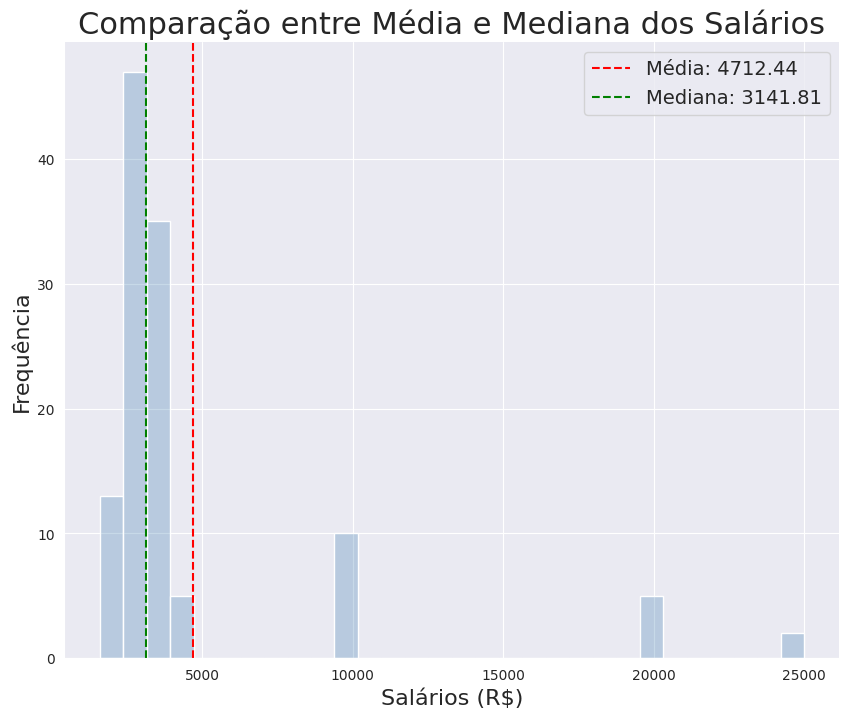

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo a semente para garantir resultados reproduzíveis
np.random.seed(123)

# Simulando dados de salários
salarios = np.concatenate([np.random.normal(3000, 500, 100), [10000] * 10, [20000] * 5, [25000] * 2])

# Criando o DataFrame
dados = pd.DataFrame(salarios, columns=['salarios'])

# Calculando a média e a mediana
media_salarios = dados['salarios'].mean()
mediana_salarios = dados['salarios'].median()

# Ajustando o tamanho do gráfico
plt.figure(figsize=(10, 8))

sns.set_style('darkgrid')
# Criando o histograma e a linha de densidade
sns.histplot(dados['salarios'], bins=30, color='steelblue', alpha=0.3)

# Adicionando as linhas para média e mediana
plt.axvline(media_salarios, color="red", linestyle="--", label=f'Média: {media_salarios:.2f}')
plt.axvline(mediana_salarios, color="green", linestyle="--", label=f'Mediana: {mediana_salarios:.2f}')

# Adicionando título e rótulos aos eixos
plt.title("Comparação entre Média e Mediana dos Salários", fontsize=22, ha='center')
plt.xlabel("Salários (R$)", fontsize=16)
plt.ylabel("Frequência", fontsize=16)

sns.despine()

# Adicionando a legenda
plt.legend(title='', fontsize=14)

plt.show()

MODA

In [ ]:
dados.salarios.mode()

,salarios
0,10000.0


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import beta

# Definir a semente para garantir resultados reproduzíveis
np.random.seed(42)

# Gerando os dados de consumo de energia (distribuição Beta com parâmetros a=10, b=4)
consumo_energia = 2 * np.round(100 * beta.rvs(10, 4, size=10000), 0)

# Criando o DataFrame
df_consumo = pd.DataFrame(consumo_energia, columns=['Consumo'])

# Exibindo as primeiras linhas
df_consumo.head()

,Consumo
0,154.0
1,146.0
2,148.0
3,126.0
4,182.0


In [ ]:
# Exibindo as medidas
medidas = {
    'media': df_consumo['Consumo'].mean(),
    'mediana': df_consumo['Consumo'].median(),
    'moda': df_consumo['Consumo'].mode()[0]
}
medidas

media = df_consumo['Consumo'].mean()
mediana = df_consumo['Consumo'].median()
moda = df_consumo['Consumo'].mode()[0]

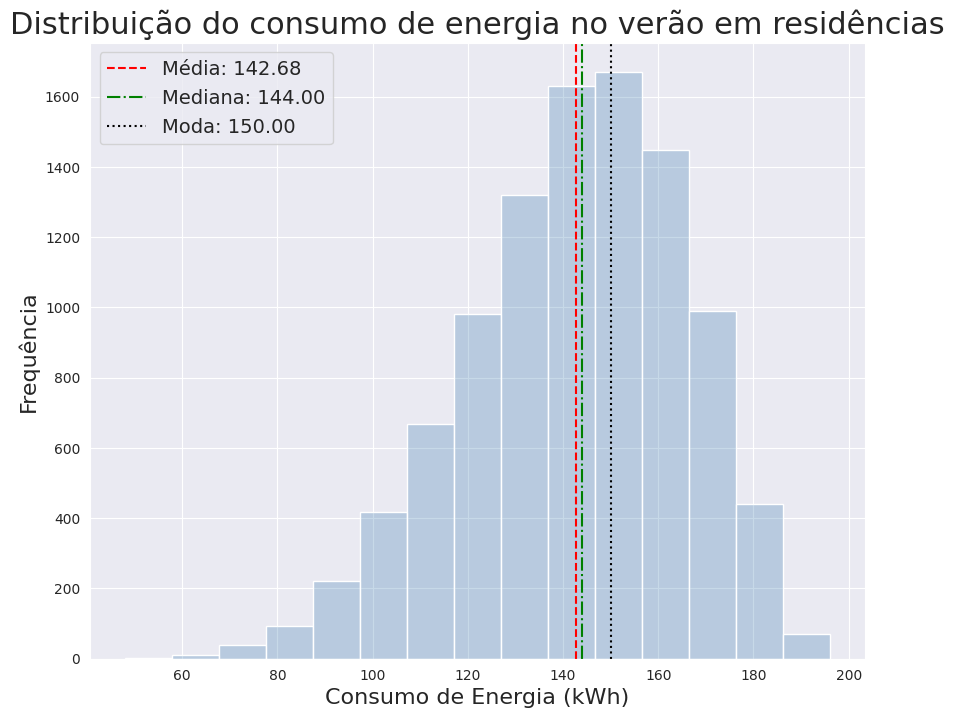

In [ ]:
# Ajustando o tamanho do gráfico
plt.figure(figsize=(10, 8))

sns.set_style('darkgrid')

# Criando o histograma
sns.histplot(df_consumo['Consumo'], bins=15, color='steelblue', alpha=0.3)

# Adicionando as linhas para média, mediana e moda
plt.axvline(media, color="red", linestyle="--", label=f'Média: {media:.2f}')
plt.axvline(mediana, color="green", linestyle="-.", label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color="black", linestyle=":", label=f'Moda: {moda:.2f}')

# Títulos e rótulos
plt.title('Distribuição do consumo de energia no verão em residências', fontsize=22, ha='center')
plt.xlabel('Consumo de Energia (kWh)', fontsize=16)
plt.ylabel('Frequência', fontsize=16)

# Adicionando a legenda
plt.legend(title='', fontsize=14)

# Exibindo o gráfico
plt.show()

In [ ]:
# Carregando bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
url = "https://raw.githubusercontent.com/alura-cursos/estatistica-r-frequencias-medidas/refs/heads/main/dados/colaboradores.csv"
colaboradores = pd.read_csv(url)

# Definindo o salário mínimo e classes
sm = 1412

# Definindo as classes salariais com base no salário mínimo
classes = [colaboradores['remuneracao'].min(), sm * 2, sm * 4, sm * 8, sm * 12, colaboradores['remuneracao'].max()]

classes

[1920.57, 2824, 5648, 11296, 16944, 32084.55]

In [ ]:
# Definindo as classes salariais com base nas faixas
labels = ['E', 'D', 'C', 'B', 'A']
colaboradores['faixa_salarial'] = pd.cut(colaboradores['remuneracao'], bins=classes, labels=labels, right=True, include_lowest=True)

colaboradores

,id_colaborador,nome,sexo_biologico,idade,cargo,nota_desempenho,remuneracao,faixa_salarial
0,DIR000001,Théo Sales,Masculino,45,Diretor(a),Bom,29950.79,A
1,DIR000002,Isis Pinto,Feminino,45,Diretor(a),Bom,27261.07,A
2,DIR000003,Isabelly Garcia,Feminino,45,Diretor(a),Bom,25635.61,A
3,DIR000004,Nina Pereira,Feminino,45,Diretor(a),Excelente,27678.60,A
4,DIR000005,Otávio Azevedo,Masculino,46,Diretor(a),Excelente,32084.55,A
...,...,...,...,...,...,...,...,...
11085,REP011086,Nicolas Mendes,Masculino,40,Repositor(a),Bom,3340.72,D
11086,REP011087,Maria Luísa Câmara,Feminino,48,Repositor(a),Insuficiente,3330.98,D
11087,REP011088,Allana da Mota,Feminino,28,Repositor(a),Excelente,3382.03,D
11088,REP011089,Bruno Rezende,Masculino,36,Repositor(a),Bom,3088.46,D


In [ ]:
# Tabela de frequência das faixas salariais
frequencias = colaboradores['faixa_salarial'].value_counts().sort_index()

frequencias

# Agrupar por faixa salarial e calcular a frequência e porcentagem
classes_salariais = colaboradores.groupby('faixa_salarial', observed=False ).size().reset_index(name='frequencia')

# Calcular a porcentagem
classes_salariais['porcentagem'] = (classes_salariais['frequencia'] / len(colaboradores)) * 100

# Ordenar pelas classes salariais
classes_salariais = classes_salariais.sort_values(by='faixa_salarial')

classes_salariais

,faixa_salarial,frequencia,porcentagem
0,E,948,8.548242
1,D,8070,72.768260
2,C,1944,17.529306
3,B,93,0.838593
4,A,35,0.315600


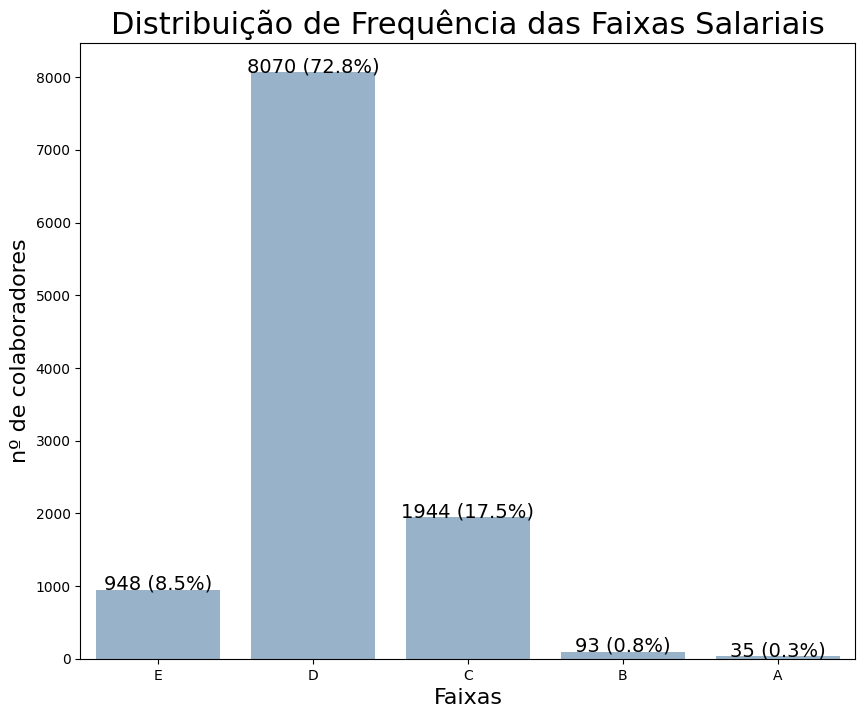

In [ ]:
# Ajustando o tamanho do gráfico
plt.figure(figsize=(10, 8))

# Criando o gráfico de barras
sns.barplot(x='faixa_salarial', y='frequencia', data=classes_salariais, color='steelblue', alpha=0.6)

# Adicionando título e rótulos aos eixos
plt.title('Distribuição de Frequência das Faixas Salariais', fontsize=22, ha='center')
plt.xlabel('Faixas', fontsize=16)
plt.ylabel('nº de colaboradores', fontsize=16)

# Adicionando rótulos de frequência e porcentagem acima das barras
for i, row in classes_salariais.iterrows():
    plt.text(i, row['frequencia'] + 2, f"{row['frequencia']} ({round(row['porcentagem'], 1)}%)",
             ha='center', fontsize=14)

# Exibindo o gráfico
plt.show()

DESVIO MÉDIO ABSOLUTO

In [2]:
import numpy as np
# Gerando dados simulados de consumo de energia (kWh)
np.random.seed(42)
consumo = 2 * np.round(100 * np.random.beta(10, 4, size=10000), 0)

# Calculando a média
media_consumo = np.mean(consumo)

# Calculando o Desvio Médio Absoluto (MAD)
mad = np.mean(np.abs(consumo - media_consumo))

# Exibindo os resultados
print(f"Média do Consumo: {round(media_consumo, 2)} kWh")
print(f"Desvio Médio Absoluto: {round(mad, 2)} kWh")

Média do Consumo: 142.68 kWh
Desvio Médio Absoluto: 18.74 kWh


VARIÂNCIA E DESVIO PADRÃO

In [3]:
# Gerando dados simulados de consumo de energia (kWh)
np.random.seed(42)
consumo = 2 * np.round(100 * np.random.beta(10, 4, size=10000), 0)

# Calculando a média
media_consumo = np.mean(consumo)

# Calculando a variância
variancia = np.var(consumo)

# Calculando o desvio padrão
desvio_padrao = np.std(consumo)

# Calculando o Desvio Médio Absoluto (MAD)
mad = np.mean(np.abs(consumo - media_consumo))

# Exibindo os resultados
print(f"Média do Consumo: {round(media_consumo, 2)} kWh")
print(f"Variância: {round(variancia, 2)} kWh^2")
print(f"Desvio Padrão: {round(desvio_padrao, 2)} kWh")
print(f"Desvio Médio Absoluto: {round(mad, 2)} kWh")

Média do Consumo: 142.68 kWh
Variância: 539.39 kWh^2
Desvio Padrão: 23.22 kWh
Desvio Médio Absoluto: 18.74 kWh
